In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [21]:
df_general = pd.read_excel('../data/data_26june2023_without Personal info.xls', index_col=0)

In [22]:
df_audio = pd.read_excel('../data/data_26june2023_without Personal info.xls', index_col=0, sheet_name='Audiological data')

In [23]:
df_ha = pd.read_excel('../data/data_26june2023_without Personal info.xls', index_col=0, sheet_name='HAs efficiency assessment')

In [24]:
df_ha = df_ha.drop(' ', axis=1)
df_audio = df_audio.drop(' ', axis=1)

In [25]:
df = df_audio.join(df_ha)

In [26]:
df = df.join(df_general)

In [27]:
df['Gender: F, M'] = df['Gender: F, M'].str.lower()

In [29]:
df['Gender: F, M'].value_counts()

f    331
m    180
Name: Gender: F, M, dtype: int64

In [30]:
df['Gender: F, M'] = df['Gender: F, M'].replace({'f': 1, 'm': 0})

In [32]:
df['Gender: F, M'].value_counts(normalize=True)

1.0    0.64775
0.0    0.35225
Name: Gender: F, M, dtype: float64

In [15]:
df = df.replace('[^0-9]+', np.nan, regex=True)
df = df.astype(float)

- Построим регрессию и посмотрим остатки
- остатки от линии регрессии и посмотреть корреляцию с тугоухостью с PTA
- дальше попробовать по PTA предсказывать остатки


- multisilabic вклад аппарата
- multisilabical с аппаратом в разных шумах

- multisilabical без аппарата с шумом и в тишине


- prediction

In [16]:
k1 = 'RuMatrix in quiet right, dB SPL'
k2 = 'RuMatrix in quiet left, dB SPL'
m1 = 'Monosyllabic speech in quiet, right, %'
m2 = 'Monosyllabic speech in quiet, left, %'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


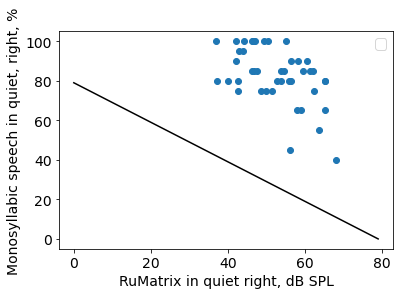

In [624]:
plt.scatter(x=df[k1], y=df[m1])
plt.xlabel(k1)

plt.ylabel(m1)
plt.legend()

x = list(range(0, 80))
plt.plot(x[::-1], x, color='k')

# Linear regression Mono Rumatrix

## Right

In [625]:
df_tmp = df.dropna(subset=[k1, m1])

In [626]:
from sklearn.linear_model import LinearRegression

X, y = df_tmp[k1].values, df_tmp[m1]
reg = LinearRegression().fit(X.reshape(-1, 1), y)
reg.score(X.reshape(-1, 1), y)

0.26237142528894086

In [627]:
import matplotlib
# matplotlib.style.use(["seaborn-notebook"])

In [628]:
plt.rcParams.update({'font.size': 14})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


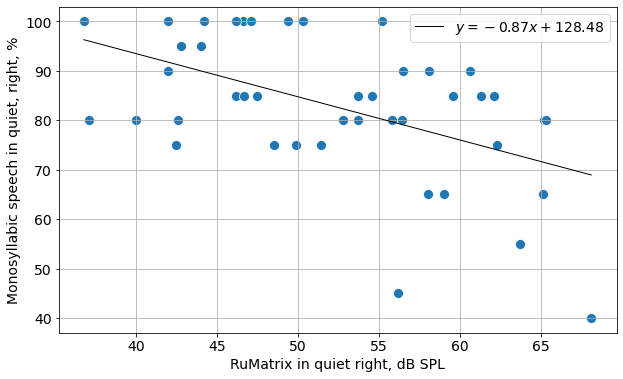

In [629]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[k1], y=df[m1], s=100)
plt.xlabel(k1)

plt.ylabel(m1)
plt.legend()
plt.grid()

sns.lineplot(x=X, y=reg.predict(X.reshape(-1, 1)),
         color='k', 
         label=fr'$y = {round(reg.coef_[0], 2)}x + {round(reg.intercept_, 2)}$',linewidth=1.0)

plt.legend()

plt.savefig('../figure/regr_mono_rumatrix_right.eps', format='eps', dpi=1200, bbox_inches = 'tight',
    pad_inches = 0)

### Find errors

In [630]:
y_predict = reg.predict(X.reshape(-1, 1))
df['error_right'] = y - y_predict

In [631]:
# plt.figure(figsize=(12, 6))
# plt.scatter(x=df[k1], y=df[m1])
# plt.xlabel(k1)

# plt.ylabel(m1)
# plt.legend()
# plt.grid()

# plt.plot(X, reg.predict(X.reshape(-1, 1)),
#          color='k', 
#          label=fr'$y = {round(reg.coef_[0], 2)}x + {round(reg.intercept_, 2)}$',linewidth=1.0)

# plt.legend()

# plt.savefig('../figure/noiseHA_obs_pred_multi.eps', format='eps', dpi=1200, bbox_inches = 'tight',
#     pad_inches = 0)

## Left

In [632]:
df_tmp = df.dropna(subset=[k2, m2])

X, y = df_tmp[k2].values, df_tmp[m2]
reg_left = LinearRegression().fit(X.reshape(-1, 1), y)
reg_left.score(X.reshape(-1, 1), y)

0.22060040454850371

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


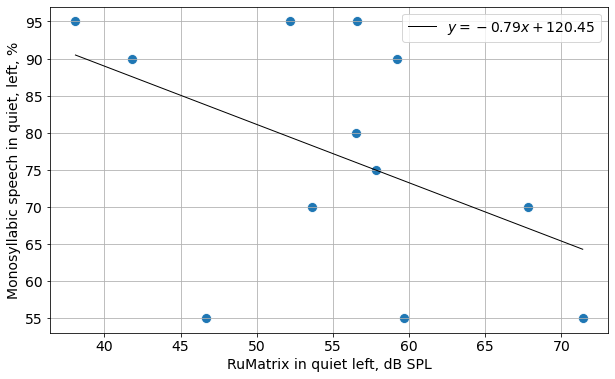

In [633]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[k2], y=df[m2], s=100)
plt.xlabel(k2)

plt.ylabel(m2)
plt.legend()
plt.grid()

sns.lineplot(x=X, y=reg_left.predict(X.reshape(-1, 1)),
         color='k', 
         label=fr'$y = {round(reg_left.coef_[0], 2)}x + {round(reg_left.intercept_, 2)}$',linewidth=1.0)

plt.legend()

plt.savefig('../figure/regr_mono_rumatrix_left.eps', format='eps', dpi=1200, bbox_inches='tight',
    pad_inches=0)

Если большое положительное отличие, то это низкие когнитивные способности.
Если большое отрицательное отличие, то человек за счет когнитивных способностей многое додумывает. То есть PTA тесты должны быть плохими тоже

### Find errors

In [611]:
y_predict = reg.predict(X.reshape(-1, 1))
df['error_left'] = y - y_predict

## Correlation

In [612]:
['Right HL degree: 0=no HL; 1-4; 5=deafness',
 'Left HL degree: 0=no HL; 1-4; 5=deafness']

['Right HL degree: 0=no HL; 1-4; 5=deafness',
 'Left HL degree: 0=no HL; 1-4; 5=deafness']

In [613]:
m = df[['PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC',
    'Right HL degree: 0=no HL; 1-4; 5=deafness', 
    'mean PTA AC right 0.5,1,2,4 ', 'error_right']].corr(method='spearman')

KeyError: "['error_right'] not in index"

In [614]:
print(m['error_right'].to_latex())

KeyError: 'error_right'

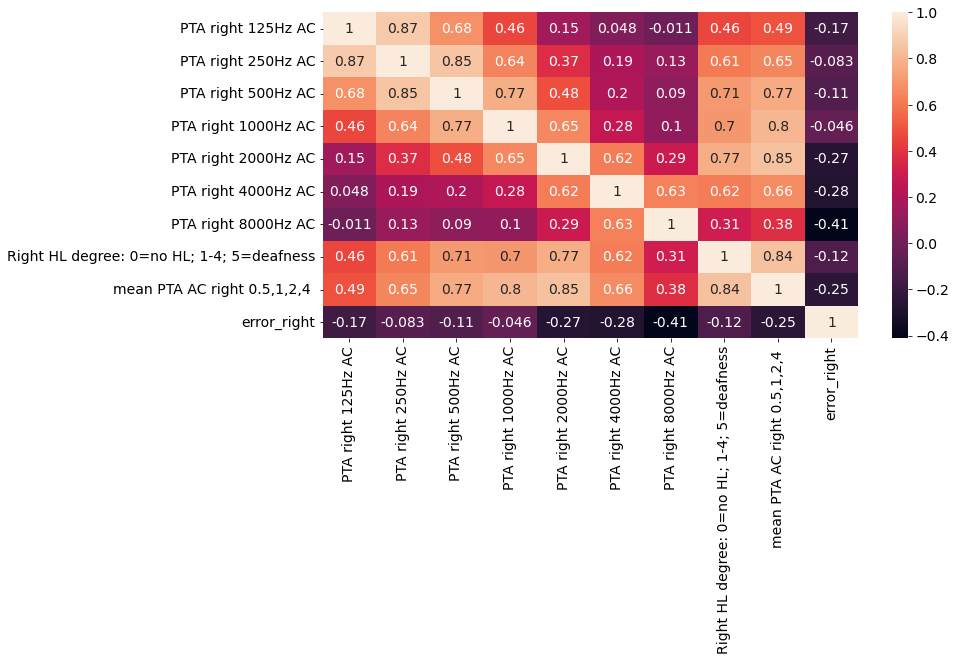

In [175]:
plt.figure(figsize=(12, 6))
sns.heatmap(m, annot =True)
plt.savefig('../figure/correlation_right.eps', format='eps', dpi=1200, bbox_inches='tight',
    pad_inches=0)

Чем меньше значения PTA, тем хуже слух, значение в ячейках обозначают минимальные dB, при которых человек на данной частоте слышит

Чем меньше остатки, тем больше значение PTA. 

То есть пациенты ниже линии регрессии должны PTA проходить хуже, 

In [169]:
df.iloc[df[['PTA left 125Hz AC', 'PTA left 250Hz AC',
]

,PTA right 4000Hz AC,PTA left 250Hz AC
#,,
1.0,70.0,NaN
2.0,120.0,NaN
3.0,70.0,NaN
4.0,60.0,NaN
5.0,45.0,NaN
...,...,...
509.0,45.0,20.0
510.0,50.0,10.0
511.0,85.0,15.0


In [191]:
df.columns

Index(['PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'UCL le

In [192]:
m = df[['PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'Left HL degree: 0=no HL; 1-4; 5=deafness', 
        'mean PTA AC left 0.5,1,2,4', 
    
    'error_left']].corr(method='spearman')


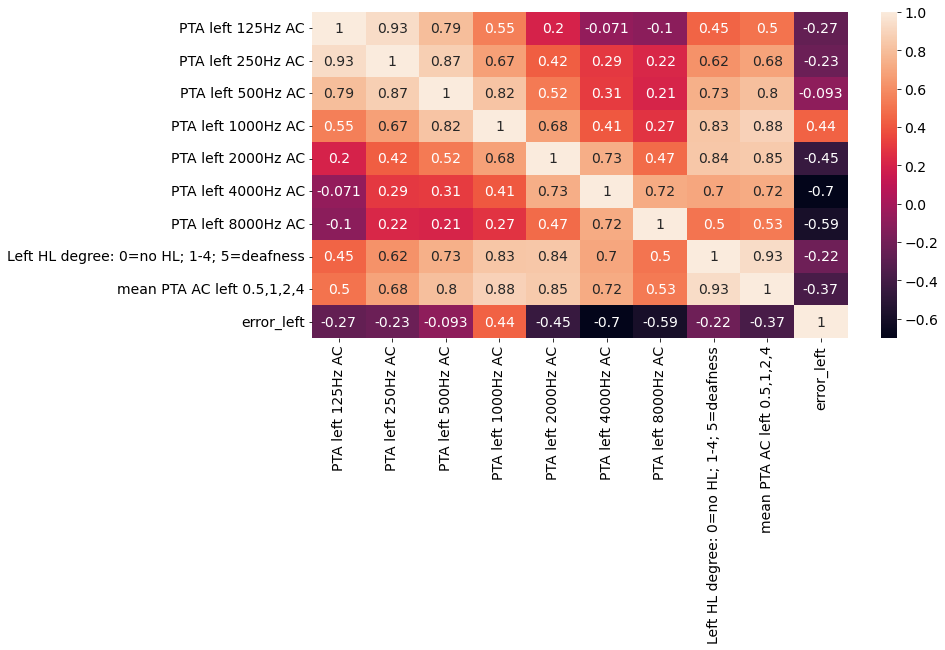

In [193]:
plt.figure(figsize=(12, 6))
sns.heatmap(m, annot =True)
plt.savefig('../figure/correlation_right.eps', format='eps', dpi=1200, bbox_inches='tight',
    pad_inches=0)

In [194]:
print(m['error_left'].to_latex())

\begin{tabular}{lr}
\toprule
{} &  error\_left \\
\midrule
PTA left 125Hz AC                        &   -0.267919 \\
PTA left 250Hz AC                        &   -0.230935 \\
PTA left 500Hz AC                        &   -0.093048 \\
PTA left 1000Hz AC                       &    0.439761 \\
PTA left 2000Hz AC                       &   -0.448775 \\
PTA left 4000Hz AC                       &   -0.700161 \\
PTA left 8000Hz AC                       &   -0.590500 \\
Left HL degree: 0=no HL; 1-4; 5=deafness &   -0.218357 \\
mean PTA AC left 0.5,1,2,4               &   -0.374782 \\
error\_left                               &    1.000000 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_358701/1417638079.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(m['error_left'].to_latex())


<AxesSubplot:xlabel='Education: 0 school; 1 technical college; 2 university', ylabel='RuMatrix in quiet right, dB SPL'>

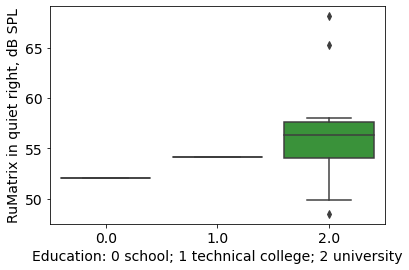

In [148]:
sns.boxplot(data=df, y='RuMatrix in quiet right, dB SPL', 
            x='Education: 0 school; 1 technical college; 2 university')

In [144]:
df.columns

Index(['PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'UCL le

# HA

- multisilabic вклад аппарата
- multisilabical с аппаратом в разных шумах

In [587]:
def plot_kde(df, cols, figure_name, xa0, xa1, ya0, ya1):
    color_list =  ['tab:blue','tab:orange', 'tab:green']
    fig, ax = plt.subplots(figsize=(8, 6))
    

    for num, col in enumerate(cols):
        sns.kdeplot(data=df, x=col, label=col, ax=ax, clip=(0, 100))

        kdeline = ax.lines[num]
        mean = df[col].mean()
        xs = kdeline.get_xdata()
        ys = kdeline.get_ydata()
        height = np.interp(mean, xs, ys)
        ax.vlines(mean, 0, height, color=color_list[num], ls=':')
        ax.fill_between(xs, 0, ys, facecolor=color_list[num], alpha=0.2)
        
    plt.text(df[cols[0]].mean()-xa0, ya0, f"mean={round(df[cols[0]].mean())}", color=color_list[0])    
    plt.text(df[cols[1]].mean()-xa1, ya1, f"mean={round(df[cols[1]].mean())}", color=color_list[1])
    
    plt.legend(loc='upper left')
    plt.grid()
    plt.xlabel('')
#     ax.set_rasterized(True)
    plt.savefig(figure_name, format='svg', dpi=200, bbox_inches='tight', pad_inches=0)

In [588]:
col = ['Multisyllabic speech without HA in quiet FF, %',
       'Multisyllabic speech with HA in quiet FF, %']

In [589]:
xa0, xa1, ya0, ya1 = 13, 18, 0.011, 0.021

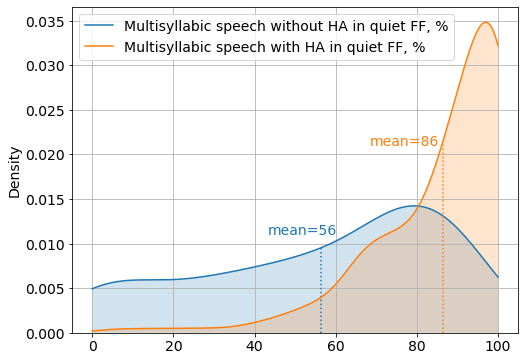

In [590]:
plot_kde(df, col, '../figure/multisillabic_ha.svg', xa0, xa1, ya0, ya1)

In [591]:
col = ['Multisyllabic speech without HA in quiet FF, %',
       'Multisyllabic speech without HA in babble noise FF, %']

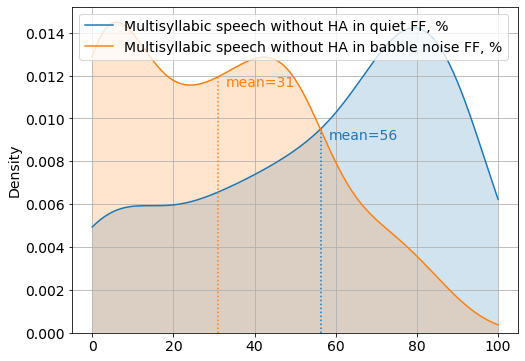

In [592]:
plot_kde(df, col, '../figure/multisillabic_noise.svg', -2, -2, 0.009, 0.0115)

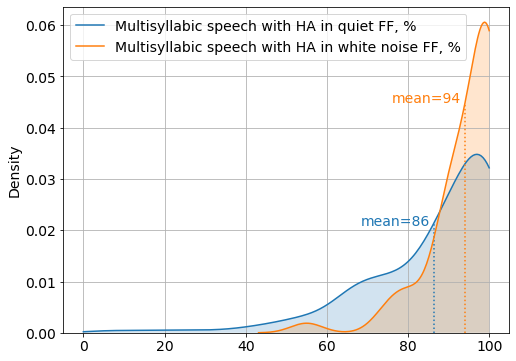

In [593]:
col = ['Multisyllabic speech with HA in quiet FF, %', 
       'Multisyllabic speech with HA in white noise FF, %']
plot_kde(df, col, '../figure/test.eps', 18, 18, 0.021, 0.045)

In [594]:
def plot_kde3(df, cols, figure_name, xa0, xa1, xa2,  ya0, ya1, ya2):
    color_list =  ['tab:blue','tab:orange', 'tab:green']
    fig, ax = plt.subplots(figsize=(8, 6))
    

    for num, col in enumerate(cols):
        sns.kdeplot(data=df, x=col, label=col, ax=ax, clip=(0, 100))


        kdeline = ax.lines[num]
        mean = df[col].mean()
        xs = kdeline.get_xdata()
        ys = kdeline.get_ydata()
        height = np.interp(mean, xs, ys)
        ax.vlines(mean, 0, height, color=color_list[num], ls=':')
        ax.fill_between(xs, 0, ys, facecolor=color_list[num], alpha=0.2)
        
    plt.text(df[cols[0]].mean()-xa0, ya0, f"mean={round(df[cols[0]].mean())}", color=color_list[0])    
    plt.text(df[cols[1]].mean()-xa1, ya1, f"mean={round(df[cols[1]].mean())}", color=color_list[1])
    plt.text(df[cols[2]].mean()-xa2, ya2, f"mean={round(df[cols[1]].mean())}", color=color_list[2])
    
    plt.legend(loc='upper left')
    plt.grid()
    plt.xlabel('')
#     ax.set_rasterized(True)
    plt.savefig(figure_name, format='svg', dpi=200, bbox_inches='tight', pad_inches=0)

In [595]:
col = ['Multisyllabic speech with HA in quiet FF, %', 
       'Multisyllabic speech with HA in white noise FF, %',
       'Multisyllabic speech with HA in babble noise FF, %']

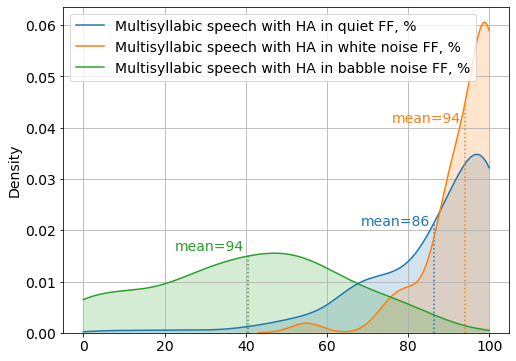

In [596]:
plot_kde3(df, col, '../figure/multisillabic_noise_HA.svg', 18, 18, 18, 0.021, 0.041, 0.016)

In [599]:
col = ['Monosyllabic speech HA in quiet FF, %',
      'Monosyllabic speech HA in white noise FF, %']

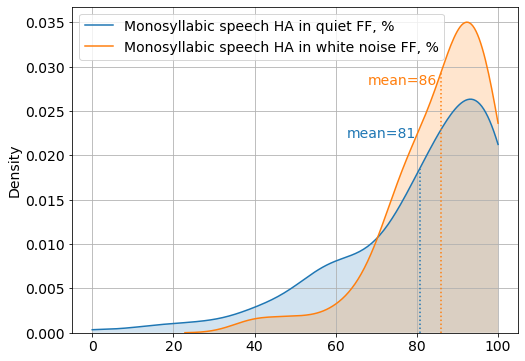

In [600]:
plot_kde(df, col, '../figure/monosyllabic_noise_HA.svg', 18, 18, 0.022, 0.028)

In [525]:
# plot_kde(df, col, '../figure/multisillabic_ha.svg', xa0, xa1, ya0, ya1)

In [17]:
df = df.rename({'error_right': 'residual_right','error_left': 'residual_left'}, axis=1)

In [18]:
df.to_csv('../data/prepared/tmp.csv')